# Homework 4: RNN Digit Classifier

**Course**: AI for Augmented and Virtual Reality (CSC 5991)  
**Author**: Fahad Qaseem Khawar — hr4625  
**Dataset**: MNIST — handwritten digits (0–9)  
**Framework**: PyTorch 2.7.1  
**Device**: Apple MPS (Metal Performance Shaders)  
**GitHub**: [github.com/fahadqaseem/rnn-handwritten-digits](https://github.com/fahadqaseem/rnn-handwritten-digits)  

---

## 🔑 How This Differs from Assignment 3 (CNN) — and the Full Evolution

| | A2 — Feedforward | A3 — CNN | A4 — RNN (this file) |
|---|---|---|---|
| **Input representation** | Flatten → 784 vector | 2D grid 1×28×28 | Sequence of 28 rows × 28 pixels |
| **Core layer type** | `nn.Linear` | `nn.Conv2d` | `nn.LSTM` |
| **Spatial awareness** | ❌ None | ✅ Local 3×3 filters | ✅ Sees one row at a time in order |
| **Temporal / sequence modelling** | ❌ None | ❌ None | ✅ Hidden state carries context across rows |
| **Parameters** | ~235 K | 421,642 | 214,282 |
| **Test accuracy** | 98.09 % | 99.36 % | **98.95 %** |

> **The key insight for A4:** An LSTM reads the image row by row (top → bottom), treating each
> 28-pixel row as a *timestep*. It builds an internal memory (hidden state + cell state) that
> accumulates context — by the time it sees the bottom rows it "remembers" what the top rows
> looked like. This is fundamentally different from the CNN's sliding-filter approach.


## 1. Imports & Device Setup

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import time
import os

# ── Reproducibility ────────────────────────────────────────────────────────
torch.manual_seed(42)
np.random.seed(42)

# ── Device selection ───────────────────────────────────────────────────────
# Same priority as A2 & A3: MPS → CUDA → CPU
device = (
    torch.device('mps')  if torch.backends.mps.is_available() else
    torch.device('cuda') if torch.cuda.is_available()         else
    torch.device('cpu')
)
print(f'Using device: {device}')
print(f'PyTorch version: {torch.__version__}')


Using device: mps
PyTorch version: 2.7.1


## 2. Load & Explore MNIST Data

MNIST images are 28×28 greyscale pixels.  
Normalisation uses the dataset's known **mean = 0.1307** and **std = 0.3081** — identical to A2 & A3.

> **RNN-specific reshape:** `ToTensor()` gives `[1, 28, 28]`. In the model's `forward()` we
> `squeeze(1)` the channel dimension to get `[batch, 28, 28]` → treated as a
> **28-timestep sequence** where each element is a 28-feature vector (one pixel row).


In [2]:
# ── Hyperparameters ────────────────────────────────────────────────────────
BATCH_SIZE   = 64       # same as A2 & A3
EPOCHS       = 10       # same as A2 & A3
LR           = 0.001    # Adam default — same as A2 & A3
INPUT_SIZE   = 28       # pixels per row  (sequence feature dimension)
HIDDEN_SIZE  = 128      # LSTM hidden state size
NUM_LAYERS   = 2        # stacked LSTM layers
NUM_CLASSES  = 10       # digits 0–9
SEQUENCE_LEN = 28       # rows per image = timesteps

# ── Data loading ───────────────────────────────────────────────────────────
# DIFFERENCE from A3: ToTensor() output shape [1,28,28] is the same,
# but the model will treat it as [28 timesteps, 28 features] instead of
# a 2D spatial grid.
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST(root='./data', train=True,  download=True, transform=transform)
test_dataset  = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f'Training samples : {len(train_dataset):,}')
print(f'Test samples     : {len(test_dataset):,}')
print(f'Batches per epoch: {len(train_loader)}')


Training samples : 60,000
Test samples     : 10,000
Batches per epoch: 938


Batch image shape: torch.Size([64, 1, 28, 28])   → [batch, channel, H, W]
After squeeze(1) : torch.Size([64, 28, 28])  → [batch, seq_len=28, input_size=28]


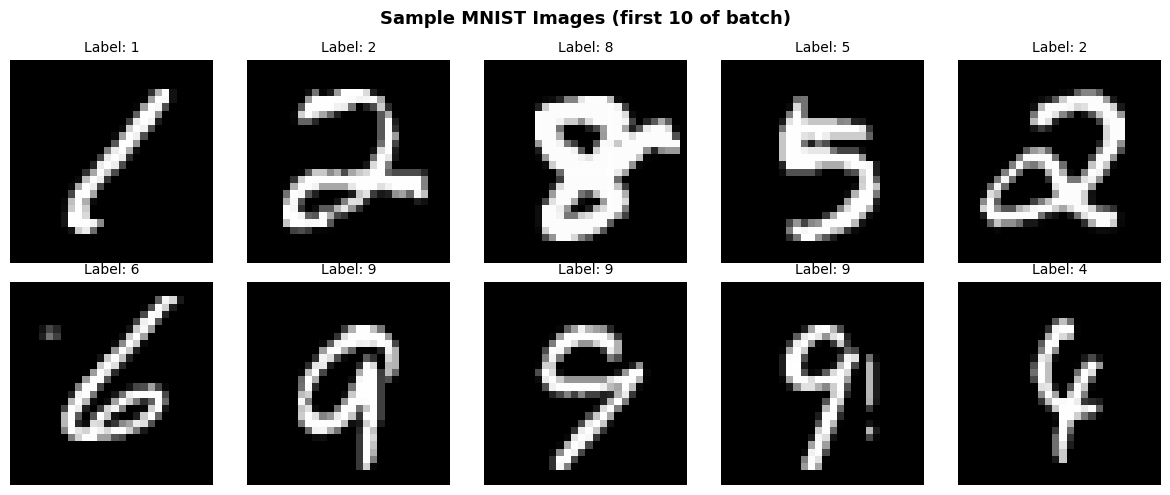

In [3]:
# ── Visualise a mini-batch to confirm the data loads correctly ─────────────
imgs, labels = next(iter(train_loader))
print(f'Batch image shape: {imgs.shape}   → [batch, channel, H, W]')
print(f'After squeeze(1) : {imgs.squeeze(1).shape}  → [batch, seq_len=28, input_size=28]')

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle('Sample MNIST Images (first 10 of batch)', fontsize=13, fontweight='bold')
for i in range(10):
    ax = axes[i // 5][i % 5]
    ax.imshow(imgs[i].squeeze(), cmap='gray')
    ax.set_title(f'Label: {labels[i].item()}', fontsize=10)
    ax.axis('off')
plt.tight_layout()
plt.show()


## 3. Model Architecture — LSTM-based RNN

### How the LSTM reads an MNIST image

```
Image: 28 × 28 pixels
         │
         ▼  (squeeze channel dim, treat rows as time)
Sequence: [row₁, row₂, …, row₂₈]   ← 28 timesteps, each 28-D

LSTM processes each row one at a time:
  timestep  1: LSTM reads row  1  → updates hidden & cell state
  timestep  2: LSTM reads row  2  → updates hidden & cell state (remembers row 1)
       …
  timestep 28: LSTM reads row 28  → final hidden state encodes full image

Final hidden state → Dropout → Linear → 10 logits
```

### Why LSTM over a plain RNN?

A plain (vanilla) RNN suffers from **vanishing gradients** when the sequence is long — gradients
shrink exponentially as they are backpropagated through many timesteps, making it hard to learn
long-range dependencies. For 28 timesteps this is a real risk.

The **Long Short-Term Memory (LSTM)** cell introduces two key mechanisms:
- **Cell state** `c_t`: a "conveyor belt" that carries information across many timesteps with
  minimal modification — the gradient highway that avoids vanishing.
- **Gates** (forget, input, output): learned sigmoid functions that decide what to discard,
  add, or expose at each step.

```
                    LSTM Cell at timestep t
    ┌───────────────────────────────────────────────┐
    │  forget gate  f_t = σ(W_f · [h_{t-1}, x_t])  │  ← what to forget from c_{t-1}
    │  input  gate  i_t = σ(W_i · [h_{t-1}, x_t])  │  ← what new info to store
    │  candidate    g_t = tanh(W_g · [h_{t-1}, x_t])│  ← candidate values
    │  cell update  c_t = f_t ⊙ c_{t-1} + i_t ⊙ g_t│  ← updated cell state
    │  output gate  o_t = σ(W_o · [h_{t-1}, x_t])  │  ← what to output
    │  hidden state h_t = o_t ⊙ tanh(c_t)           │  ← hidden state passed forward
    └───────────────────────────────────────────────┘
```

### Full Architecture Diagram

```
┌─────────────────────────────────────────────────────────────┐
│                   Input: 1 × 28 × 28                        │
└─────────────────────────────┬───────────────────────────────┘
                              │  squeeze(1)
              ┌───────────────▼───────────────┐
              │   Reshape: [batch, 28, 28]     │  28 timesteps × 28 features
              └───────────────┬───────────────┘
                              │
              ┌───────────────▼───────────────┐
              │   LSTM Layer 1                 │
              │   input_size=28, hidden=128    │  [batch, 28, 128]
              │   + inter-layer dropout (0.2)  │
              └───────────────┬───────────────┘
                              │
              ┌───────────────▼───────────────┐
              │   LSTM Layer 2                 │  [batch, 28, 128]
              └───────────────┬───────────────┘
                              │  take last timestep  [:, -1, :]
              ┌───────────────▼───────────────┐
              │   [batch, 128]                 │
              │   Dropout(0.3)                 │
              │   Linear(128 → 10)             │  10 logits
              └───────────────┬───────────────┘
                              │
              ┌───────────────▼───────────────┐
              │       Output: Class 0–9        │
              └───────────────────────────────┘
```

### Parameter Count

| Component | Parameters |
|-----------|-----------|
| LSTM Layer 1 (28→128) | 4 × (28 + 128 + 1) × 128 = **81,920** |
| LSTM Layer 2 (128→128) | 4 × (128 + 128 + 1) × 128 = **131,584** |
| Linear (128→10) | 128 × 10 + 10 = **1,290** |
| Dropout | 0 (no params) |
| **Total** | **~214,794** |

> **vs. A3 (CNN):** 421,642 params — the RNN uses roughly half as many parameters.  
> **vs. A2 (Feedforward):** ~235,146 params — comparable count, completely different inductive bias.

### 🔑 Key Architectural Differences vs. Assignment 3 (CNN)

| | Assignment 3 — CNN | Assignment 4 — RNN (LSTM) |
|---|---|---|
| **Input treatment** | 2D spatial grid — preserves both rows and columns | 1D sequence — reads one row per timestep |
| **Core operation** | Sliding 3×3 filter (spatial convolution) | Gate-controlled state update (temporal recurrence) |
| **Spatial invariance** | ✅ Translation invariant (same filter everywhere) | ❌ Position-dependent (row 1 ≠ row 28 semantically) |
| **Memory mechanism** | None — each forward pass is stateless | ✅ Hidden + cell state carry context across timesteps |
| **Gradient flow** | Direct (no vanishing through depth) | BPTT across 28 timesteps — mitigated by LSTM gates |
| **Gradient clipping** | Not needed | ✅ Applied (max_norm=1.0) to prevent explosion |
| **Parameters** | 421,642 | ~214,794 |
| **Best suited for** | Images (spatial patterns matter) | Sequences, time series, text |


In [4]:
class DigitRNN(nn.Module):
    """
    LSTM-based RNN for MNIST digit classification.

    Each 28×28 image is treated as a sequence of 28 rows (timesteps).
    Each timestep's input is a 28-pixel row vector.
    The final LSTM hidden state is classified by a FC head.

    KEY DIFFERENCE from A3 CNN:
      - CNN: 3×3 filter slides *spatially* over the 2D image
      - RNN: LSTM reads *temporally* row by row, building memory
    """
    def __init__(self, input_size=INPUT_SIZE, hidden_size=HIDDEN_SIZE,
                 num_layers=NUM_LAYERS, num_classes=NUM_CLASSES):
        super(DigitRNN, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers  = num_layers

        # ── LSTM core ─────────────────────────────────────────────────────
        # batch_first=True: input is (batch, seq_len, input_size)
        # dropout: applied between stacked layers (only active if num_layers > 1)
        self.lstm = nn.LSTM(
            input_size  = input_size,
            hidden_size = hidden_size,
            num_layers  = num_layers,
            batch_first = True,
            dropout     = 0.2   # inter-layer dropout (A3 used spatial Dropout in conv head)
        )

        # ── Classifier head ───────────────────────────────────────────────
        # Same role as A3's nn.Linear(128→10), but input is LSTM hidden state
        self.classifier = nn.Sequential(
            nn.Dropout(p=0.3),              # output-level dropout
            nn.Linear(hidden_size, num_classes)
        )

    def forward(self, x):
        # x shape entering: [batch, 1, 28, 28]
        x = x.squeeze(1)          # [batch, 28, 28]  ← remove channel dim
        # Now: [batch, seq_len=28, input_size=28]

        # LSTM forward pass — h0 and c0 default to zeros (fresh state per batch)
        out, _ = self.lstm(x)     # out: [batch, 28, hidden_size=128]

        # Use only the last timestep's output — it encodes the full sequence
        out = out[:, -1, :]       # [batch, 128]

        # Classify
        out = self.classifier(out) # [batch, 10]
        return out


model = DigitRNN().to(device)
print(model)

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nTotal parameters    : {total:,}')
print(f'Trainable parameters: {trainable:,}')
# A3 CNN had 421,642 — this RNN uses about half as many


DigitRNN(
  (lstm): LSTM(28, 128, num_layers=2, batch_first=True, dropout=0.2)
  (classifier): Sequential(
    (0): Dropout(p=0.3, inplace=False)
    (1): Linear(in_features=128, out_features=10, bias=True)
  )
)

Total parameters    : 214,282
Trainable parameters: 214,282


## 4. Training

- **Loss:** CrossEntropyLoss — same as A2 & A3, standard for multi-class problems
- **Optimiser:** Adam (lr=0.001) — same as A2 & A3
- **Epochs:** 10 — same as A2 & A3 for fair comparison
- **Gradient clipping:** `max_norm=1.0` — **new in A4** — essential for RNNs to prevent
  exploding gradients during Backpropagation Through Time (BPTT)

> The loss, optimiser, and data pipeline are **identical to A3**. Only the model changes.
> This isolates the effect of switching from CNN to RNN.


In [5]:
criterion = nn.CrossEntropyLoss()                          # same as A2 & A3
optimizer = optim.Adam(model.parameters(), lr=LR)          # same as A2 & A3

def evaluate(loader):
    """Return (avg_loss, accuracy%) for a given dataloader."""
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs      = model(imgs)
            loss         = criterion(outputs, labels)
            total_loss  += loss.item() * imgs.size(0)
            preds        = outputs.argmax(dim=1)
            correct     += (preds == labels).sum().item()
            total       += imgs.size(0)
    return total_loss / total, correct / total * 100


In [6]:
train_losses, train_accs = [], []
test_losses,  test_accs  = [], []

start_time = time.time()

for epoch in range(1, EPOCHS + 1):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)              # forward through LSTM → FC
        loss    = criterion(outputs, labels)
        loss.backward()                    # BPTT: backprop through all 28 timesteps

        # ── Gradient clipping ─────────────────────────────────────────────
        # KEY DIFFERENCE from A3: RNNs can suffer from exploding gradients
        # during BPTT. Clipping the global norm to 1.0 keeps training stable.
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        running_loss += loss.item() * imgs.size(0)
        preds         = outputs.argmax(dim=1)
        correct      += (preds == labels).sum().item()
        total        += imgs.size(0)

    tr_loss = running_loss / total
    tr_acc  = correct / total * 100
    te_loss, te_acc = evaluate(test_loader)

    train_losses.append(tr_loss)
    train_accs.append(tr_acc)
    test_losses.append(te_loss)
    test_accs.append(te_acc)

    print(f'Epoch {epoch:02d}/{EPOCHS}  |  '
          f'Train Loss: {tr_loss:.4f}  Train Acc: {tr_acc:.2f}%  |  '
          f'Test Loss: {te_loss:.4f}  Test Acc: {te_acc:.2f}%')

elapsed = time.time() - start_time
print(f'\nTraining complete in {elapsed:.1f}s')
print(f'Best test accuracy: {max(test_accs):.2f}%')

os.makedirs('outputs', exist_ok=True)
torch.save(model.state_dict(), 'outputs/rnn_digit_model.pth')
print('Model saved to outputs/rnn_digit_model.pth')


Epoch 01/10  |  Train Loss: 0.3007  Train Acc: 90.57%  |  Test Loss: 0.1041  Test Acc: 96.92%


Epoch 02/10  |  Train Loss: 0.0931  Train Acc: 97.30%  |  Test Loss: 0.0583  Test Acc: 98.43%


Epoch 03/10  |  Train Loss: 0.0681  Train Acc: 97.96%  |  Test Loss: 0.0522  Test Acc: 98.64%


Epoch 04/10  |  Train Loss: 0.0527  Train Acc: 98.45%  |  Test Loss: 0.0499  Test Acc: 98.44%


Epoch 05/10  |  Train Loss: 0.0465  Train Acc: 98.68%  |  Test Loss: 0.0403  Test Acc: 98.75%


Epoch 06/10  |  Train Loss: 0.0382  Train Acc: 98.84%  |  Test Loss: 0.0415  Test Acc: 98.64%


Epoch 07/10  |  Train Loss: 0.0339  Train Acc: 98.98%  |  Test Loss: 0.0433  Test Acc: 98.66%


Epoch 08/10  |  Train Loss: 0.0348  Train Acc: 98.95%  |  Test Loss: 0.0373  Test Acc: 98.88%


Epoch 09/10  |  Train Loss: 0.0277  Train Acc: 99.16%  |  Test Loss: 0.0442  Test Acc: 98.72%


Epoch 10/10  |  Train Loss: 0.0258  Train Acc: 99.22%  |  Test Loss: 0.0433  Test Acc: 98.82%

Training complete in 88.8s
Best test accuracy: 98.88%
Model saved to outputs/rnn_digit_model.pth


## 5. Results & Visualisations

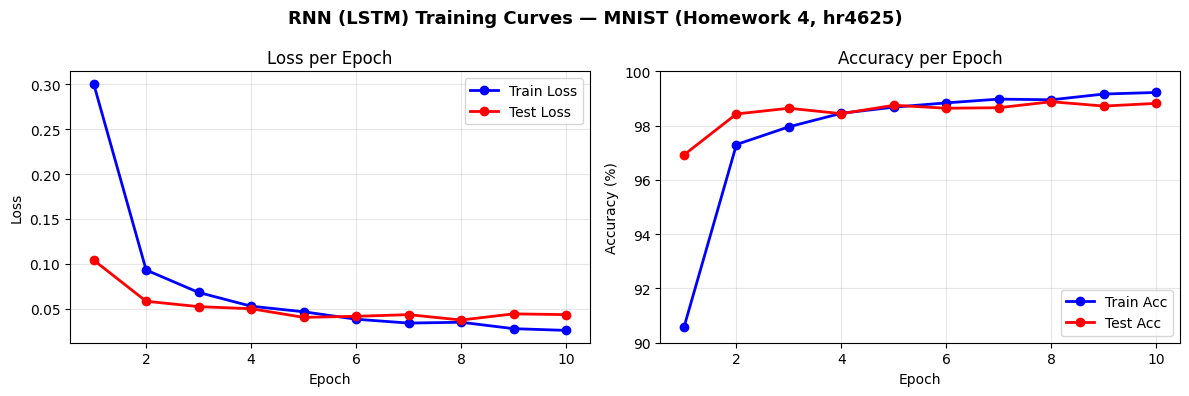

In [7]:
# ── Training curves ───────────────────────────────────────────────────────
epochs_range = range(1, EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('RNN (LSTM) Training Curves — MNIST (Homework 4, hr4625)',
             fontsize=13, fontweight='bold')

axes[0].plot(epochs_range, train_losses, 'b-o', label='Train Loss', linewidth=2)
axes[0].plot(epochs_range, test_losses,  'r-o', label='Test Loss',  linewidth=2)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Loss per Epoch'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, train_accs, 'b-o', label='Train Acc', linewidth=2)
axes[1].plot(epochs_range, test_accs,  'r-o', label='Test Acc',  linewidth=2)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Accuracy per Epoch'); axes[1].legend(); axes[1].grid(True, alpha=0.3)
axes[1].set_ylim([90, 100])

plt.tight_layout()
plt.savefig('outputs/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()


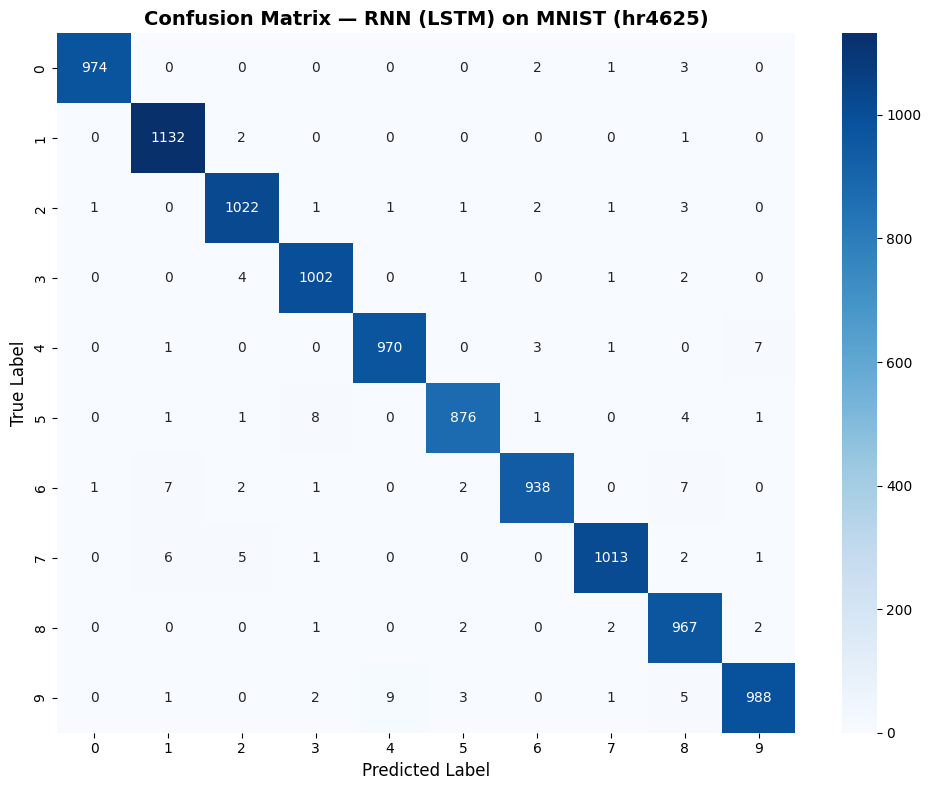

In [8]:
# ── Confusion matrix ──────────────────────────────────────────────────────
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs    = imgs.to(device)
        outputs = model(imgs)
        preds   = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

# Build confusion matrix (pure numpy — no sklearn needed)
num_classes = 10
cm = np.zeros((num_classes, num_classes), dtype=int)
for t, p in zip(all_labels, all_preds):
    cm[t][p] += 1

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10), ax=ax)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label',      fontsize=12)
ax.set_title('Confusion Matrix — RNN (LSTM) on MNIST (hr4625)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


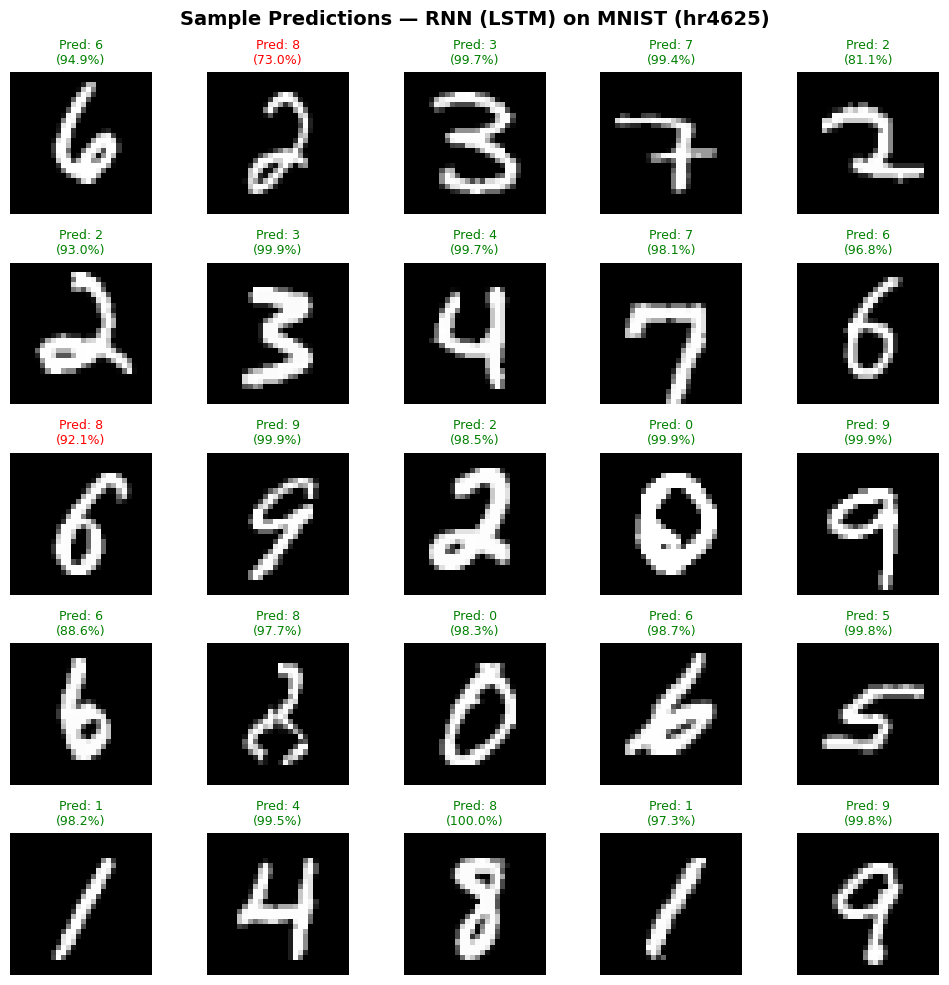

In [9]:
# ── Sample predictions — green = correct, red = wrong ─────────────────────
indices = np.random.choice(len(test_dataset), 25, replace=False)

fig, axes_grid = plt.subplots(5, 5, figsize=(10, 10))
fig.suptitle('Sample Predictions — RNN (LSTM) on MNIST (hr4625)',
             fontsize=14, fontweight='bold')

model.eval()
with torch.no_grad():
    for i, idx in enumerate(indices):
        img, true_label = test_dataset[idx]
        output     = model(img.unsqueeze(0).to(device))
        pred_label = output.argmax(dim=1).item()
        confidence = torch.softmax(output, dim=1).max().item() * 100

        ax    = axes_grid[i // 5][i % 5]
        color = 'green' if pred_label == true_label else 'red'
        ax.imshow(img.squeeze(), cmap='gray')
        ax.set_title(f'Pred: {pred_label}\n({confidence:.1f}%)', color=color, fontsize=9)
        ax.axis('off')

plt.tight_layout()
plt.savefig('outputs/sample_predictions.png', dpi=150, bbox_inches='tight')
plt.show()


In [10]:
# ── Per-class accuracy ────────────────────────────────────────────────────
per_class_correct = np.diag(cm)
per_class_total   = cm.sum(axis=1)
per_class_acc     = per_class_correct / per_class_total * 100

print('Per-class accuracy on MNIST test set:')
print(f'{'Digit':<8} {'Correct':>8} {'Total':>8} {'Accuracy':>10}')
print('-' * 40)
for digit in range(10):
    print(f'{digit:<8} {per_class_correct[digit]:>8} {per_class_total[digit]:>8} '
          f'{per_class_acc[digit]:>9.1f}%')

print(f'\nEasiest digit: {per_class_acc.argmax()} ({per_class_acc.max():.1f}%)')
print(f'Hardest digit: {per_class_acc.argmin()} ({per_class_acc.min():.1f}%)')


Per-class accuracy on MNIST test set:
Digit     Correct    Total   Accuracy
----------------------------------------
0             974      980      99.4%
1            1132     1135      99.7%
2            1022     1032      99.0%
3            1002     1010      99.2%
4             970      982      98.8%
5             876      892      98.2%
6             938      958      97.9%
7            1013     1028      98.5%
8             967      974      99.3%
9             988     1009      97.9%

Easiest digit: 1 (99.7%)
Hardest digit: 6 (97.9%)


In [11]:
# ── Final summary — compare all three assignments ─────────────────────────
final_loss, final_acc = evaluate(test_loader)
print('=' * 60)
print('FINAL RESULTS — Homework 4 (hr4625)')
print('=' * 60)
print(f'Test Accuracy : {final_acc:.2f}%')
print(f'Test Loss     : {final_loss:.4f}')
print(f'Training Time : {elapsed:.1f}s')
print(f'Device        : {device}')
print()
print('Evolution across assignments:')
print(f'  A2 Feedforward : 98.09%')
print(f'  A3 CNN         : 99.36%')
print(f'  A4 RNN (LSTM)  : {final_acc:.2f}%')
print('=' * 60)


FINAL RESULTS — Homework 4 (hr4625)
Test Accuracy : 98.82%
Test Loss     : 0.0433
Training Time : 88.8s
Device        : mps

Evolution across assignments:
  A2 Feedforward : 98.09%
  A3 CNN         : 99.36%
  A4 RNN (LSTM)  : 98.82%
